In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

LOAD DATASET

In [3]:
X_train = np.loadtxt('input.csv', delimiter =',')
Y_train = np.loadtxt('labels.csv', delimiter =',')

X_test = np.loadtxt('input_test.csv', delimiter =',')
Y_test = np.loadtxt('labels_test.csv', delimiter =',')

In [4]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train/255.0
X_test = X_test/255.0

In [5]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


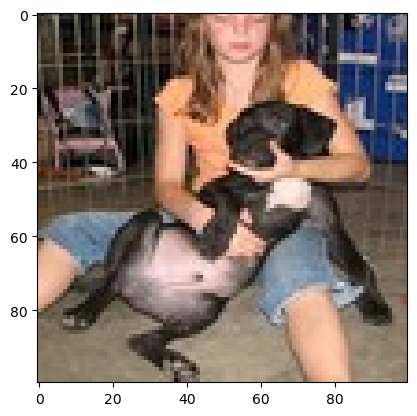

In [6]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx, :])
plt.show()

MODEL

In [7]:
model = Sequential([

    Conv2D(32, (3,3), activation = 'relu' , input_shape = (100, 100, 3)),
           MaxPooling2D((2,2)),

           Conv2D(32,(3,3), activation = 'relu'),
           MaxPooling2D((2,2)),

           Flatten(),
           Dense(64, activation = 'relu'),
           Dense(1,activation = 'sigmoid')
           ])

C:\Users\RD\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu' , input_shape = (100, 100, 3)))
model.add(MaxPooling2D((2,2)))       

model.add(Conv2D(32,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

In [9]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam' , metrics = ['accuracy'])

In [10]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 356ms/step - accuracy: 0.5150 - loss: 0.7122
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 379ms/step - accuracy: 0.5430 - loss: 0.6903
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 319ms/step - accuracy: 0.6205 - loss: 0.6592
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.6845 - loss: 0.6036
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step - accuracy: 0.7450 - loss: 0.5424


In [11]:
model.evaluate(X_test, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6775 - loss: 0.5888


[0.5887897610664368, 0.6775000095367432]

MAKEING PREDICITIONS


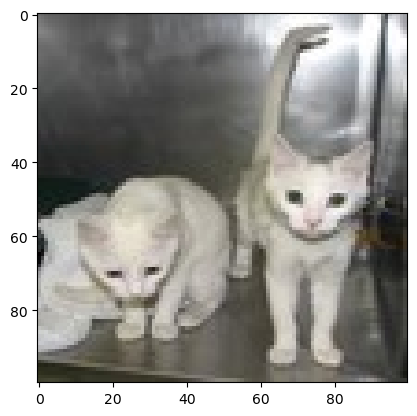

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
[[0.5731089]]
our model says it is a : cat


In [12]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100,3))
print(y_pred)
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'dog'
else:
    pred ='cat'

print("our model says it is a :",pred)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Confusion Matrix:
[[136  64]
 [ 65 135]]


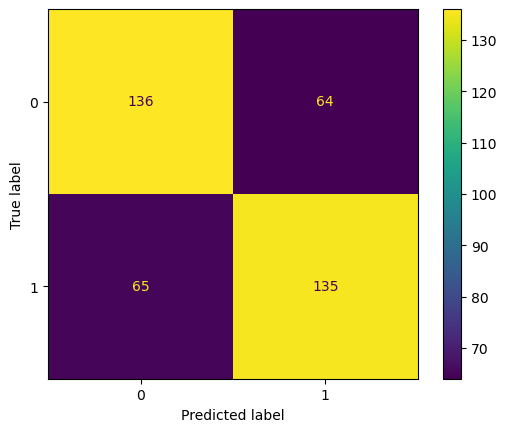

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# 0 ya 1 me convert karo
y_pred = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()